## Task 3 : Data Visualization and Dashboard

## PYTHON VISUALIZATION

In [1]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'category_sales.html', 'profit_by_category.html', 'sales_boxplot.html', 'sales_distribution.html', 'sales_distribution.png', 'sales_profit.html', 'sales_trend.html', 'superstore.db', 'Task1_Data_Loading.ipynb', 'Task2 SQL Analysis.ipynb', 'Task3 Data visualization.ipynb']


In [3]:
!dir

 Volume in drive C is OS
 Volume Serial Number is CEAC-C62C

 Directory of C:\Users\dhara\apexplanet-data-analytics\notebooks

27-06-2026  20:34    <DIR>          .
11-06-2026  00:43    <DIR>          ..
25-06-2026  17:04    <DIR>          .ipynb_checkpoints
23-06-2026  12:57         4,567,955 category_sales.html
23-06-2026  12:57         4,566,863 profit_by_category.html
23-06-2026  12:57         4,587,167 sales_boxplot.html
23-06-2026  12:57         4,574,931 sales_distribution.html
13-06-2026  21:37             2,397 sales_distribution.png
23-06-2026  12:57         4,594,923 sales_profit.html
23-06-2026  12:56         4,587,167 sales_trend.html
18-06-2026  10:59           335,872 superstore.db
13-06-2026  22:15           791,130 Task1_Data_Loading.ipynb
18-06-2026  11:42           438,347 Task2 SQL Analysis.ipynb
27-06-2026  20:34         3,823,293 Task3 Data visualization.ipynb
              11 File(s)     32,870,045 bytes
               3 Dir(s)  331,660,546,048 bytes free


In [4]:
print(os.listdir("../data"))

['.ipynb_checkpoints', 'cleaned_superstore.csv', 'Sample_Superstore_Full_Dataset.csv']


In [5]:
# load cleaned dataset
df=pd.read_csv("../data/cleaned_superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2024-10001,2024-11-23,2024-11-24,Standard Class,CUST-1001,Customer 1,Consumer,United States,San Diego,...,22280,West,PROD-2001,Furniture,Chairs,Chairs Product 1,714.90,2,0.0,103.84
1,2,CA-2024-10002,2024-04-29,2024-05-04,First Class,CUST-1002,Customer 2,Consumer,United States,Seattle,...,30926,South,PROD-2002,Technology,Phones,Phones Product 2,3585.78,9,0.3,-142.64
2,3,CA-2024-10003,2024-06-23,2024-06-26,First Class,CUST-1003,Customer 3,Consumer,United States,Houston,...,70217,East,PROD-2003,Office Supplies,Binders,Binders Product 3,481.87,2,0.2,131.91
3,4,CA-2024-10004,2024-07-12,2024-07-13,Standard Class,CUST-1004,Customer 4,Home Office,United States,Tacoma,...,39871,Central,PROD-2004,Technology,Copiers,Copiers Product 4,4429.55,6,0.1,896.04
4,5,CA-2024-10005,2024-02-10,2024-02-17,Second Class,CUST-1005,Customer 5,Home Office,United States,Houston,...,44993,East,PROD-2005,Office Supplies,Paper,Paper Product 5,2277.98,6,0.1,79.94


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         1000 non-null   int64  
 1   Order ID       1000 non-null   object 
 2   Order Date     1000 non-null   object 
 3   Ship Date      1000 non-null   object 
 4   Ship Mode      1000 non-null   object 
 5   Customer ID    1000 non-null   object 
 6   Customer Name  1000 non-null   object 
 7   Segment        1000 non-null   object 
 8   Country        1000 non-null   object 
 9   City           1000 non-null   object 
 10  State          1000 non-null   object 
 11  Postal Code    1000 non-null   int64  
 12  Region         1000 non-null   object 
 13  Product ID     1000 non-null   object 
 14  Category       1000 non-null   object 
 15  Sub-Category   1000 non-null   object 
 16  Product Name   1000 non-null   object 
 17  Sales          1000 non-null   float64
 18  Quantity 

## Line Chart

Analyze sales trends over time and identify seasonal patterns.

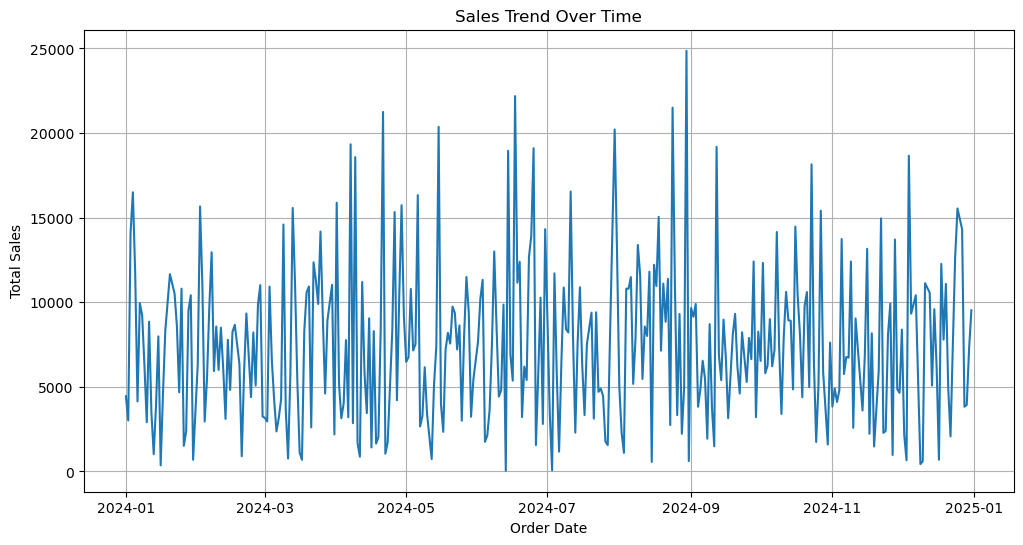

In [7]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Calculate sales over time
sales_trend = df.groupby('Order Date')['Sales'].sum()

# Create line chart
plt.figure(figsize=(12,6))
plt.plot(sales_trend.index, sales_trend.values)

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

Analyze profit trends over time and identify seasonal patterns.

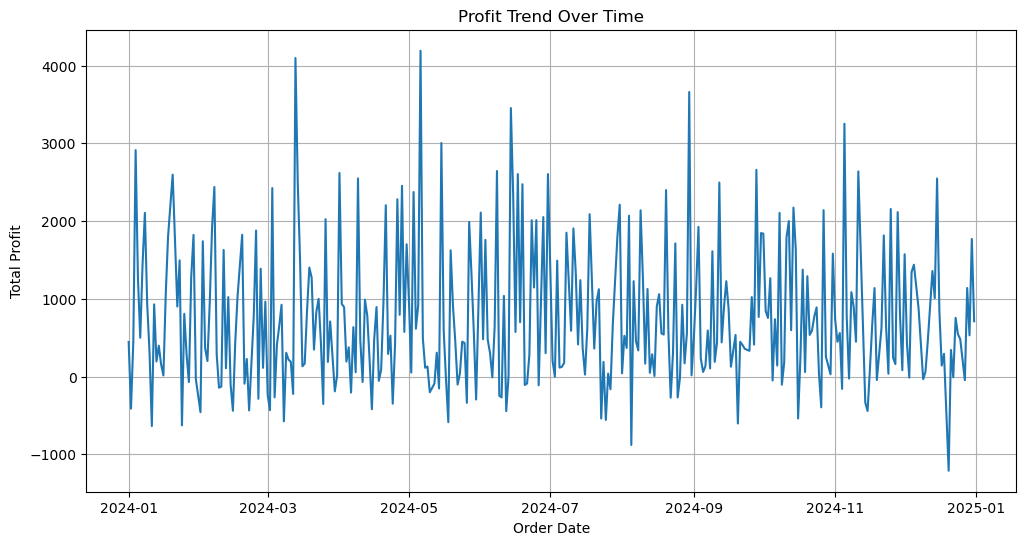

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

profit_trend = df.groupby('Order Date')['Profit'].sum()

plt.figure(figsize=(12,6))
plt.plot(profit_trend.index, profit_trend.values)

plt.title("Profit Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Profit")
plt.grid(True)

plt.show()

Analyze monthly sales trends over time and identify seasonal patterns.

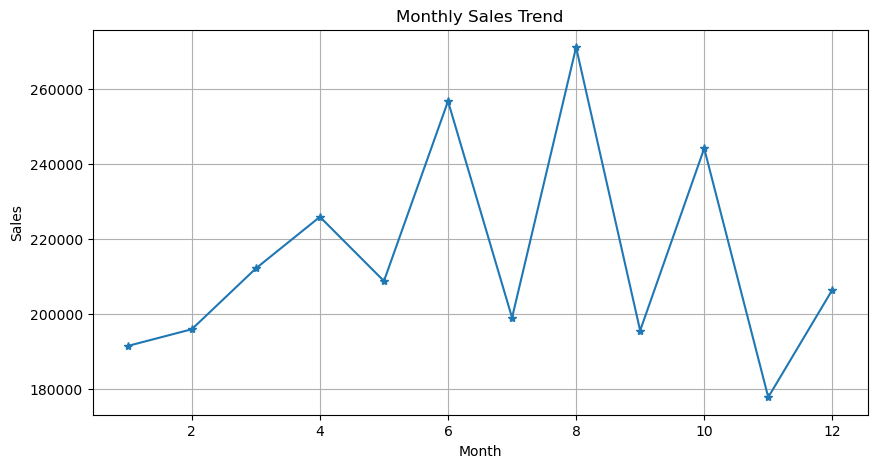

In [9]:
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='*')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

Analyze monthly profit trends over time and identify seasonal patterns.

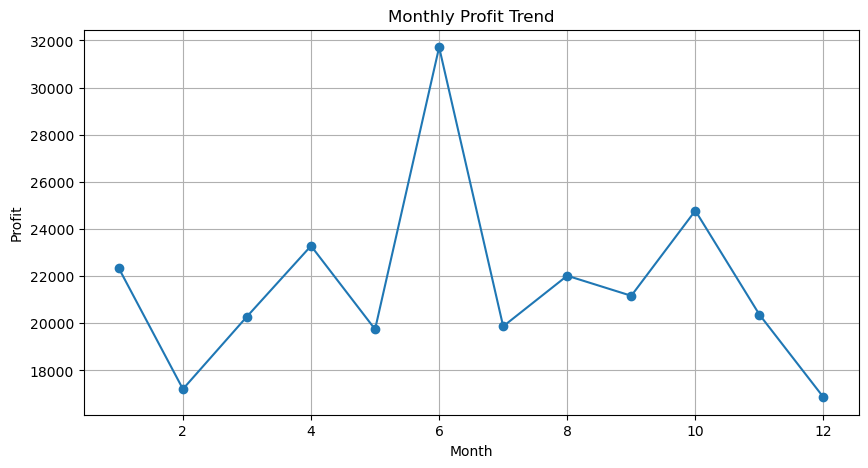

In [10]:
monthly_profit = df.groupby('Month')['Profit'].sum()

plt.figure(figsize=(10,5))
monthly_profit.plot(marker='o')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

## BAR CHART

Analyze total sales across different product categories to identify the highest revenue-generating category.

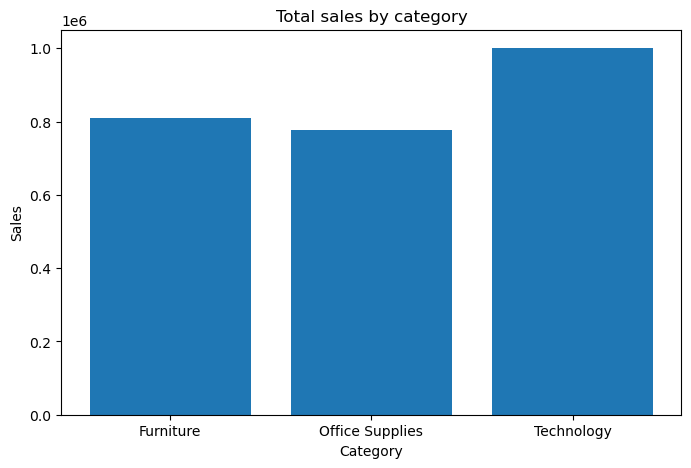

In [11]:
# Calculate total sales by category
category_sales = df.groupby('Category')['Sales'].sum()

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(category_sales.index,category_sales.values)

plt.title("Total sales by category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Analyze total profit across different product categories to identify the highest revenue-generating category.

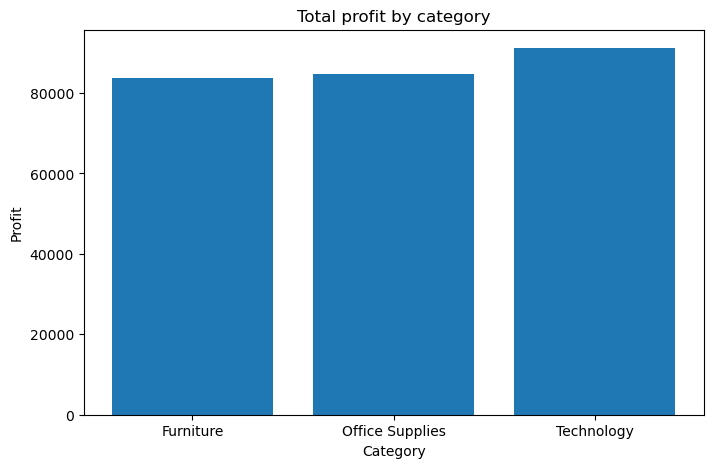

In [12]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
plt.bar(category_profit.index,category_profit.values)

plt.title("Total profit by category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

Analyze total sales across different regions to identify the highest revenue-generating region.

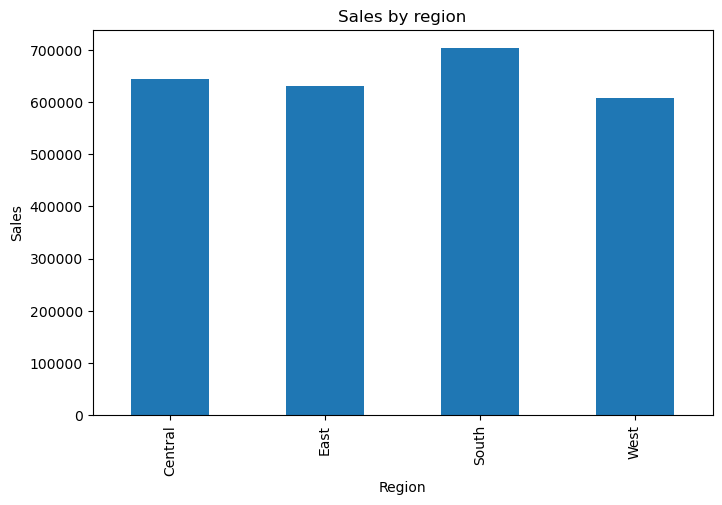

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Sales by region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

Analyze total profit across different regions to identify the highest revenue-generating region.



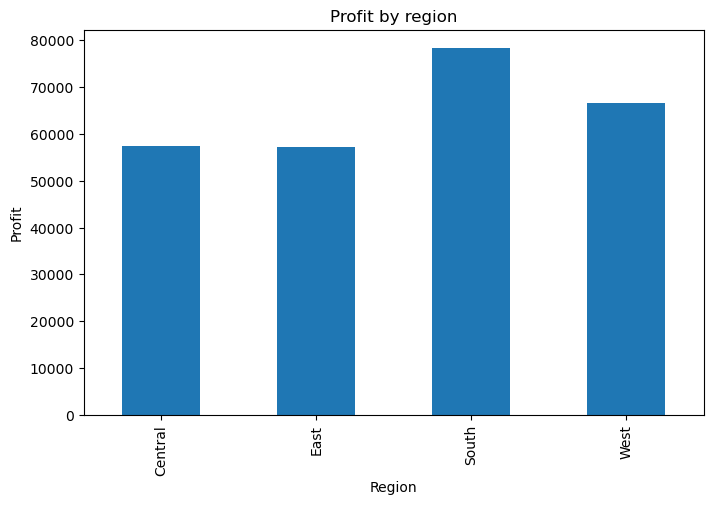

In [14]:
region_profit = df.groupby('Region')['Profit'].sum()
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

Analyze total sales across different segments to identify the highest revenue-generating segment.


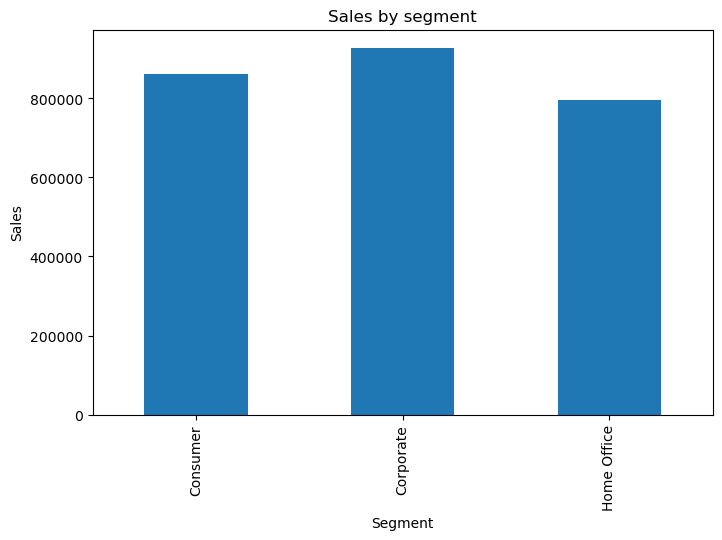

In [15]:
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title('Sales by segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.show()

Analyze total profit across different segments to identify the highest revenue-generating segment.


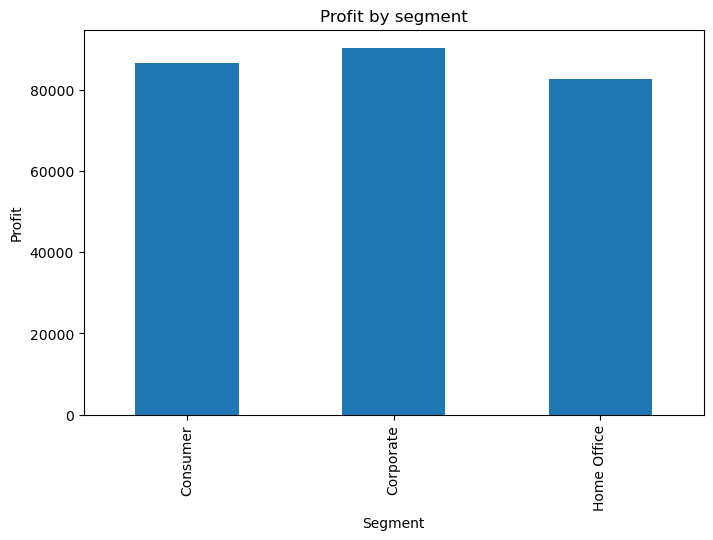

In [16]:
segment_profit = df.groupby('Segment')['Profit'].sum()
plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')
plt.title('Profit by segment')
plt.xlabel('Segment')
plt.ylabel('Profit')
plt.show()

## SCATTER PLOT

Analyze the relationship between Sales and Profit and identify any correlation between them.

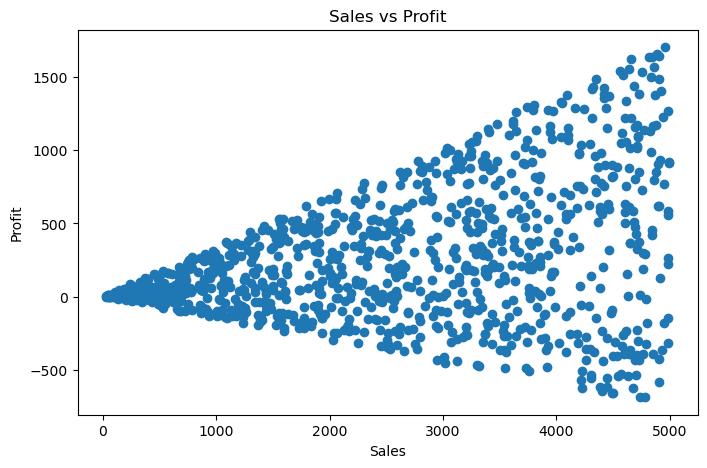

In [17]:
# Create scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'],df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## HISTOGRAM

Understand the distribution of sales values and identify sales frequency patterns.

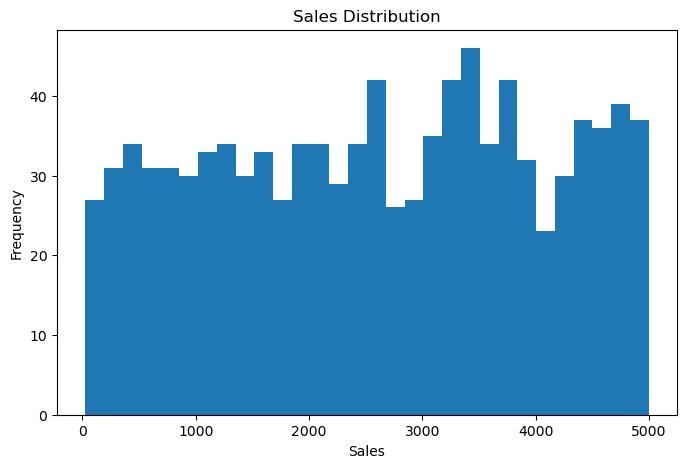

In [18]:
# Create histogram
plt.figure(figsize=(8,5))
plt.hist(df['Sales'],bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Understand the distribution of profit values and identify profit frequency patterns.

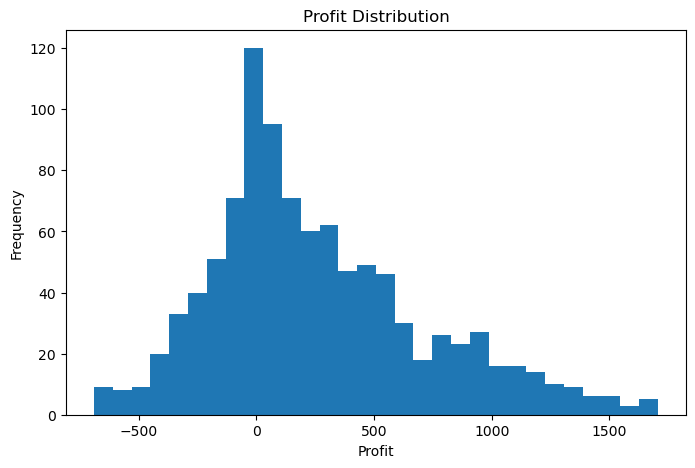

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df['Profit'],bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

## CO-RELATION MATRIX(HEATMAP)

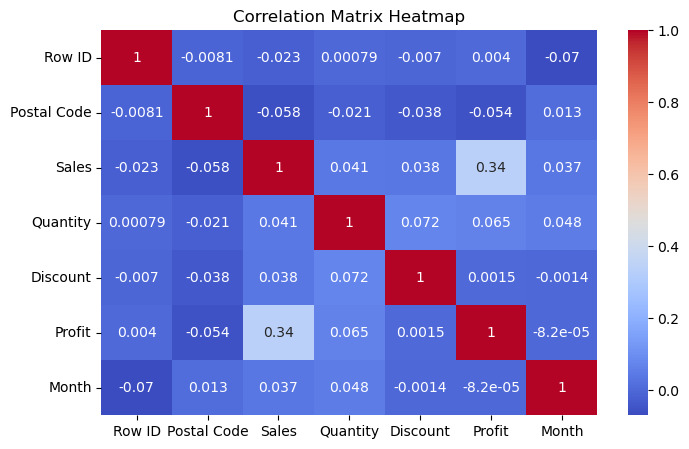

In [20]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

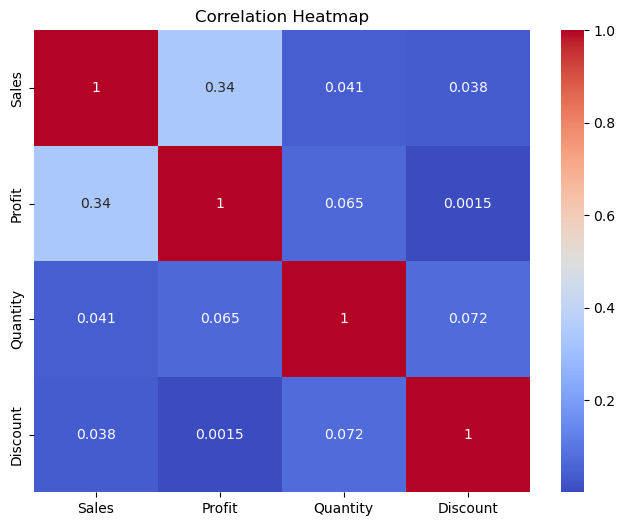

In [21]:
plt.figure(figsize=(8,6))

# corr means correlationship between these columns
corr=df[['Sales','Profit','Quantity','Discount']].corr()

# annot means tells exact numerical values instead if we take false it shows only colours not numerical values
# cmap means colourmap blue indicates weak relashionship and red indicates strong relationship

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## PAIRPLOT

This pairplot visualizes relationships among Sales, Profit, Discount, and Quantity while distinguishing customer segments using color coding. It helps identify patterns, correlations, and differences in purchasing behavior across customer segments.

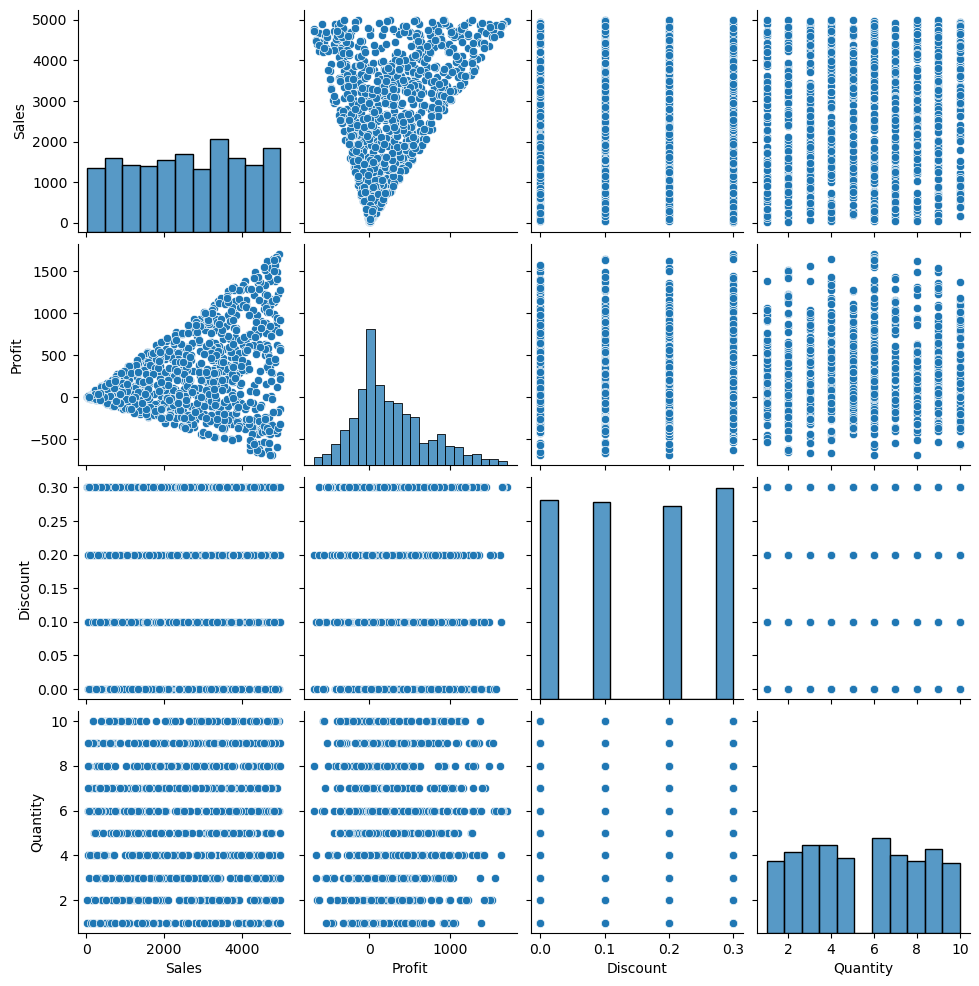

In [22]:
sns.pairplot(
    df[['Sales', 'Profit', 'Discount', 'Quantity']]
)

plt.show()

## BOXENPLOT

This boxen plot visualizes the distribution of sales across different category. It helps identify variations in sales performance, the spread of sales values, and potential outliers within each category.

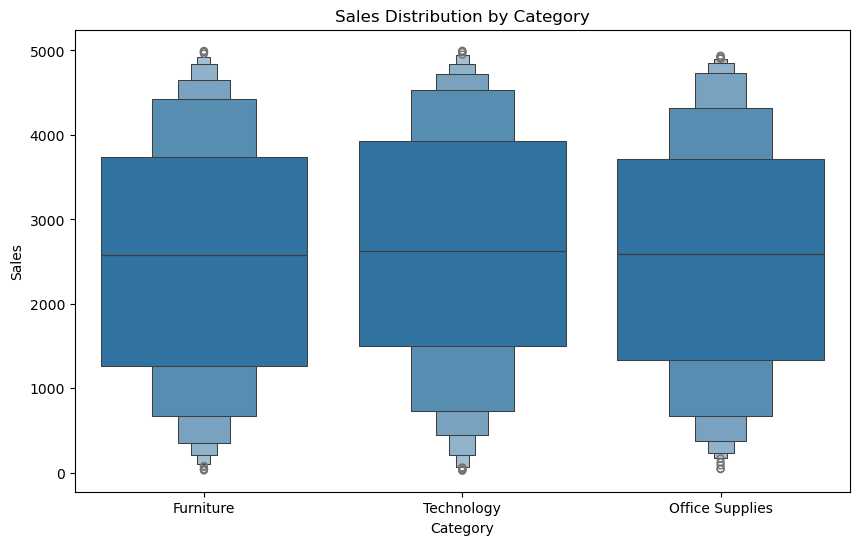

In [23]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Category',
    y='Sales',
    data=df
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

This boxen plot visualizes the distribution of profit across different category. It helps identify variations in profit performance, the spread of profit values, and potential outliers within each category.

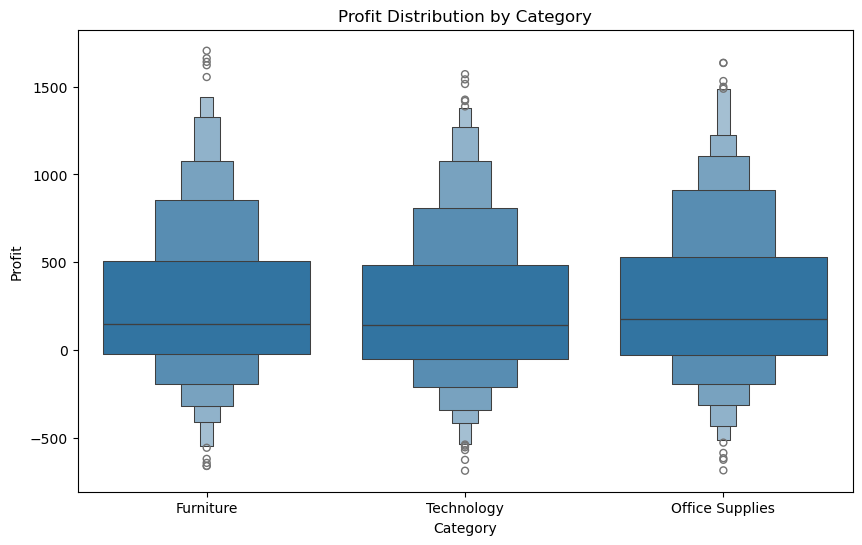

In [24]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Category',
    y='Profit',
    data=df
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

This boxen plot visualizes the distribution of sales across different regions. It helps identify variations in sales performance, the spread of sales values, and potential outliers within each region.

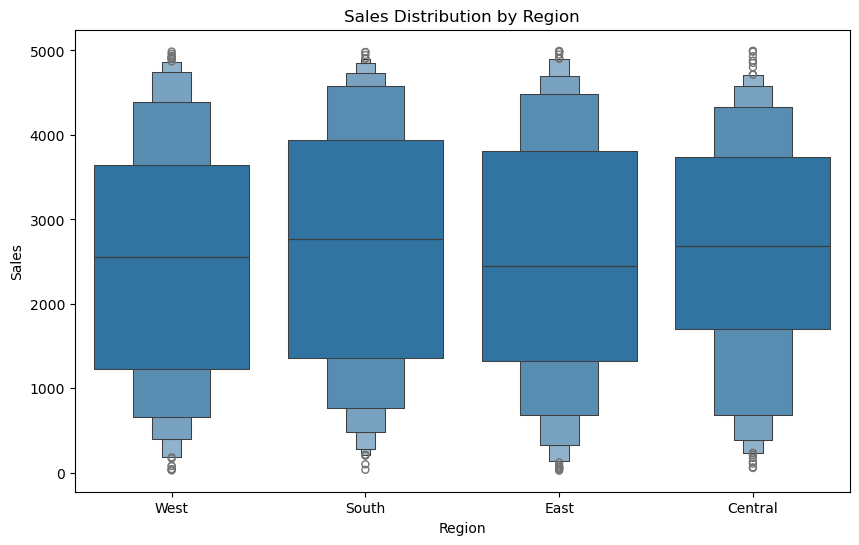

In [25]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Region',
    y='Sales',
    data=df
)

plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

This boxen plot visualizes the distribution of profit across different regions. It helps identify variations in profit performance, the spread of profit values, and potential outliers within each region.

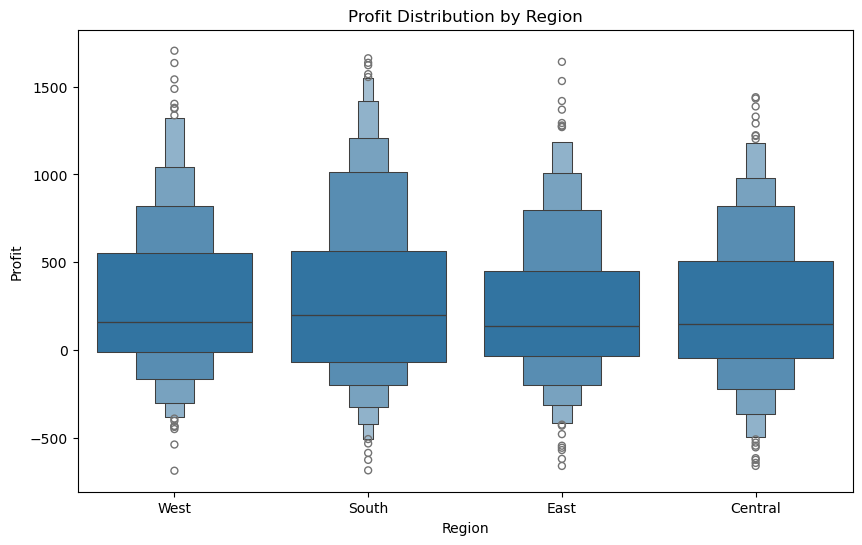

In [26]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Region',
    y='Profit',
    data=df
)

plt.title("Profit Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

This boxen plot visualizes the distribution of sales across different segment. It helps identify variations in sales performance, the spread of sales values, and potential outliers within each segment.

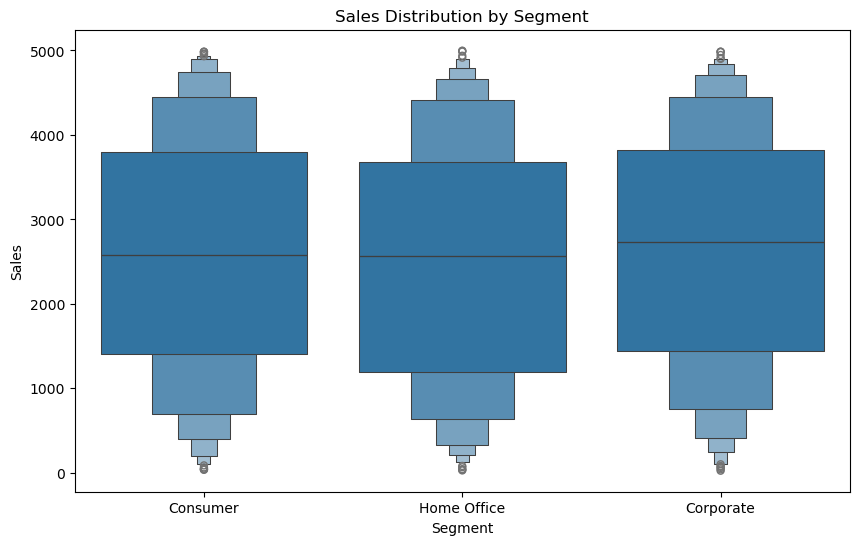

In [27]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Segment',
    y='Sales',
    data=df
)

plt.title("Sales Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

This boxen plot visualizes the distribution of profit across different segment. It helps identify variations in profit performance, the spread of profit values, and potential outliers within each segment.

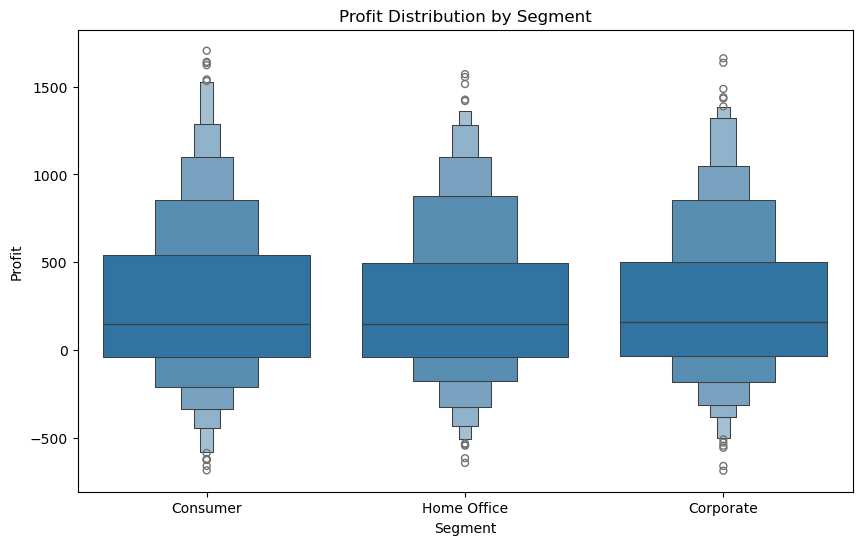

In [28]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Segment',
    y='Profit',
    data=df
)

plt.title("Profit Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.show()

## INTERACTIVE SALES BY LINE

This interactive Line chart displays total sales generated by all over time. The visualization allows users to explore sales performance through interactive features 

In [29]:
import plotly.express as px

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
sales_trend = df.groupby('Order Date')['Sales'].sum().reset_index()

line_fig = px.line(
    sales_trend,
    x='Order Date',
    y='Sales',
    title='Interactive Sales Trend Over Time'
)

line_fig.show()

This interactive Line chart displays total profit generated by all over time. The visualization allows users to explore profit performance through interactive features 

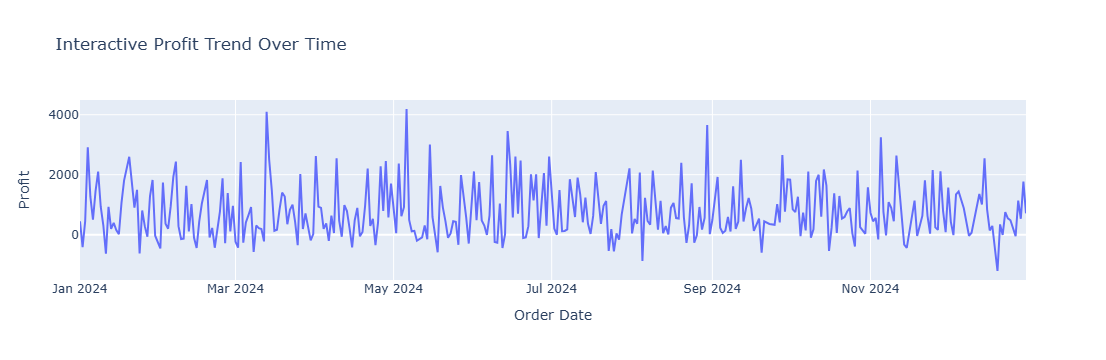

In [31]:
profit_trend = df.groupby('Order Date')['Profit'].sum().reset_index()

line_fig = px.line(
    profit_trend,
    x='Order Date',
    y='Profit',
    title='Interactive Profit Trend Over Time'
)

line_fig.show()

## INTERACTIVE BAR SALES BY CATEGORY

This interactive bar chart displays total sales generated by each category. The visualization allows users to explore category-wise sales performance through interactive features such as hover information and zoom controls.

In [32]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

bar_fig = px.bar(
    category_sales,
    x='Category',
    y='Sales',
    color='Category',
    title='Total Sales by Category'
)

bar_fig.show()

This interactive bar chart displays total profit generated by each category. The visualization allows users to explore category-wise profit performance through interactive features such as hover information and zoom controls.

In [33]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

bar_fig = px.bar(
    category_profit,
    x='Category',
    y='Profit',
    color='Category',
    title='Total Profits by Category'
)

bar_fig.show()

This interactive bar chart displays total sales generated by each region. The visualization allows users to explore region-wise sales performance through interactive features such as hover information and zoom controls.

In [34]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

bar_fig = px.bar(
    region_sales,
    x='Region',
    y='Sales',
    color='Region',
    title='Total Sales by Region'
)

bar_fig.show()

This interactive bar chart displays total profit generated by each region. The visualization allows users to explore region-wise profit performance through interactive features such as hover information and zoom controls.

In [35]:
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

bar_fig = px.bar(
    region_profit,
    x='Region',
    y='Profit',
    color='Region',
    title='Total Profit by Region'
)

bar_fig.show()

This interactive bar chart displays total sales generated by each customer segment. The visualization allows users to explore segment-wise sales performance through interactive features such as hover information and zoom controls.

In [36]:
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

bar_fig = px.bar(
    segment_sales,
    x='Segment',
    y='Sales',
    color='Segment',
    title='Total Sales by Segment'
)

bar_fig.show()

This interactive bar chart displays total profit generated by each customer segment. The visualization allows users to explore segment-wise profit performance through interactive features such as hover information and zoom controls.

In [37]:
segment_profit = df.groupby('Segment')['Profit'].sum().reset_index()

bar_fig = px.bar(
    segment_profit,
    x='Segment',
    y='Profit',
    color='Segment',
    title='Total Profits by Segment'
)

bar_fig.show()

## INTERACTIVE SCATTER PLOT

This interactive scatter plot displays total sales vs profit. The visualization allows users to explore sales vs profit performance through interactive features.

In [38]:
scatter_fig = px.scatter(
    df,
    x='Sales',
    y='Profit',
    color='Category',
    size='Quantity',
    hover_data=['Region'],
    title='Sales vs Profit'
)

scatter_fig.show()

## INTERACTIVE HISTOGRAM

This interactive histogram displays total sales. The visualization allows users to explore sales performance through interactive features.

In [39]:
hist_fig = px.histogram(
    df,
    x='Sales',
    nbins=30,
    color='Category',
    title='Sales Distribution'
)

hist_fig.show()

This interactive histogram displays total profit. The visualization allows users to explore profit performance through interactive features.



In [40]:
hist_fig = px.histogram(
    df,
    x='Profit',
    nbins=30,
    color='Category',
    title='Profit Distribution'
)

hist_fig.show()

## INTERACTIVE PIE CHART

This interactive pie chart displays total sales generated by each category. The visualization allows users to explore category-wise sales performance through interactive features 

In [41]:
sales_category = df.groupby('Category')['Sales'].sum().reset_index()

pie_fig = px.pie(
    sales_category,
    values='Sales',
    names='Category',
    title='Sales Contribution by Category'
)

pie_fig.show()

This interactive pie chart displays total profits generated by each category. The visualization allows users to explore category-wise profit performance through interactive features



In [42]:
profit_category = df.groupby('Category')['Profit'].sum().reset_index()

pie_fig = px.pie(
    profit_category,
    values='Profit',
    names='Category',
    title='Profit Contribution by Category'
)

pie_fig.show()

This interactive pie chart displays total sales generated by each region. The visualization allows users to explore region-wise sales performance through interactive features 

In [43]:
sales_region = df.groupby('Region')['Sales'].sum().reset_index()

pie_fig = px.pie(
    sales_region,
    values='Sales',
    names='Region',
    title='Sales Contribution by Region'
)

pie_fig.show()

This interactive pie chart displays total profit generated by each region. The visualization allows users to explore region-wise profit performance through interactive features



In [44]:
profit_region = df.groupby('Region')['Profit'].sum().reset_index()

pie_fig = px.pie(
    profit_region,
    values='Profit',
    names='Region',
    title='Profit Contribution by Region'
)

pie_fig.show()

This interactive pie chart displays total sales generated by each segment. The visualization allows users to explore segment-wise sales performance through interactive features 

In [45]:
sales_segment = df.groupby('Segment')['Sales'].sum().reset_index()

pie_fig = px.pie(
    sales_segment,
    values='Sales',
    names='Segment',
    title='Sales Contribution by Segment'
)

pie_fig.show()

This interactive pie chart displays total profits generated by each segment. The visualization allows users to explore segment-wise profit performance through interactive features


In [46]:
profit_segment = df.groupby('Segment')['Profit'].sum().reset_index()

pie_fig = px.pie(
    profit_segment,
    values='Profit',
    names='Segment',
    title='Profit Contribution by Segment'
)

pie_fig.show()

## INTERACTIVE BOX CHART

This interactive box chart displays total sales generated by each category. The visualization allows users to explore category-wise sales performance through interactive features



In [47]:
box_fig = px.box(
    df,
    x='Category',
    y='Sales',
    color='Category',
    title='Sales Distribution by Category'
)

box_fig.show()

This interactive box chart displays total profit generated by each category. The visualization allows users to explore categoy-wise profit performance through interactive features

In [48]:
box_fig = px.box(
    df,
    x='Category',
    y='Profit',
    color='Category',
    title='Profit Distribution by Category'
)

box_fig.show()

This interactive box chart displays total sales generated by each region. The visualization allows users to explore region-wise sales performance through interactive features


In [49]:
box_fig = px.box(
    df,
    x='Region',
    y='Sales',
    color='Region',
    title='Sales Distribution by Region'
)

box_fig.show()

This interactive box chart displays total profit generated by each region. The visualization allows users to explore region-wise profit performance through interactive features

In [50]:
box_fig = px.box(
    df,
    x='Region',
    y='Profit',
    color='Region',
    title='Profit Distribution by Region'
)

box_fig.show()

This interactive box chart displays total sales generated by each segment. The visualization allows users to explore sgment-wise sales performance through interactive features


In [51]:
box_fig = px.box(
    df,
    x='Segment',
    y='Sales',
    color='Segment',
    title='Sales Distribution by Segment'
)

box_fig.show()

This interactive box chart displays total profit generated by each segment. The visualization allows users to explore segment-wise profit performance through interactive features

In [52]:
box_fig = px.box(
    df,
    x='Segment',
    y='Profit',
    color='Segment',
    title='Profit Distribution by Segment'
)

box_fig.show()

## EXPORTING PLOTS AS HTML

In [53]:
line_fig.write_html("sales_trend.html")

In [54]:
bar_fig.write_html("category_sales.html")
scatter_fig.write_html("sales_profit.html")
hist_fig.write_html("sales_distribution.html")
pie_fig.write_html("profit_by_category.html")
box_fig.write_html("sales_boxplot.html")

In [55]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'category_sales.html', 'profit_by_category.html', 'sales_boxplot.html', 'sales_distribution.html', 'sales_distribution.png', 'sales_profit.html', 'sales_trend.html', 'superstore.db', 'Task1_Data_Loading.ipynb', 'Task2 SQL Analysis.ipynb', 'Task3 Data visualization.ipynb']
